In [183]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date, timedelta
from matplotlib.dates import MO, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter, MO
from IPython.display import HTML
from matplotlib.ticker import PercentFormatter, StrMethodFormatter

plots_filepath = 'plots/september-25/'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo

def format_date_with_suffix(date_obj):
    # 1) turn str or datetime/date into a pd.Timestamp
    ts = pd.to_datetime(date_obj)

    # 2) get the day and compute the ordinal suffix
    day = ts.day
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')

    # 3) build the final string
    #    Month name: ts.strftime('%B')
    #    Day + suffix: f'{day}{suffix}'
    #    Year: ts.year
    return f"{ts.strftime('%B')} {day}{suffix}, {ts.year}"


today = datetime.today()
date = format_date_with_suffix(today)

In [184]:
# Function to stablecoin mcap
def stablecoin_mcap_by_chain(asset, start_date, end_date, n):
    chain_colors = ['#1f1f60',
                    '#313EA5',
                    '#637BBF',
                    '#94B9D9',
                    '#333333',
                    '#5F5F5F',
                    '#8A8A8A',
                    '#A0A0A0',
                    '#B6B6B6',
                    '#CCCCCC'
                   ]
    
    df_master = None
    
    counter = 0
    
    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)

    with open(f"raw-data/defillama-raw-data/stablecoins/{asset}.json", 'r') as f:
        data = json.load(f)
    
    # Flatten records
    records = []
    for chain, chain_data in data.get('chainBalances', {}).items():
        for entry in chain_data.get('tokens', []):
            df_date = pd.to_datetime(entry.get('date'), unit='s')
            # Use circulating peggedUSD; if missing, fallback to bridgedTo peggedUSD
            value = entry.get('circulating', {}).get('peggedUSD')
            if value is None:
                value = entry.get('bridgedTo', {}).get('peggedUSD', 0)
            records.append({'date': df_date, 'chain': chain, 'peggedUSD': value})
    
    # Create DataFrame and pivot
    df_all = pd.DataFrame(records)
    df_pivot = df_all.pivot_table(index='date', columns='chain', values='peggedUSD', aggfunc='sum')
    df_pivot = df_pivot.ffill().sort_index()
    
    # Determine top_n chains *by the last date* in the index
    last_date   = df_pivot.index.max()
    last_values = df_pivot.loc[last_date]
    sorted_chains = last_values.sort_values(ascending=False)
    top_chains  = list(sorted_chains.index[:n])
    other_chains = list(sorted_chains.index[n:])
    
    # Build final DataFrame with 'Other' aggregation
    df_top = df_pivot[top_chains].copy()
    df_top['Other'] = df_pivot[other_chains].sum(axis=1)
    df_master = df_top.reset_index()

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
        
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')

    # Grab chain names
    chains = df_master.columns[1:].tolist()

    # Calculate 7-day trailing averages for each chain column
    df_master[chains] = df_master[chains].rolling(window=7, min_periods=1).mean()
    
    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[chain] for chain in chains]
    
    # Create color mapping with special case for Hyperliquid L1
    colors = []
    color_index = 0
    for chain in chains:
        if chain == 'Hyperliquid L1':
            colors.append('#09b882')
        if chain == 'Other':
            colors.append('#CCCCCC')
        else:
            colors.append(chain_colors[color_index % len(chain_colors)])
            color_index += 1
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=chains,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000000:.0f}b'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.18))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    ax.set_title(f'{asset} Market Cap by Chain')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{asset}-mcap-by-chain.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

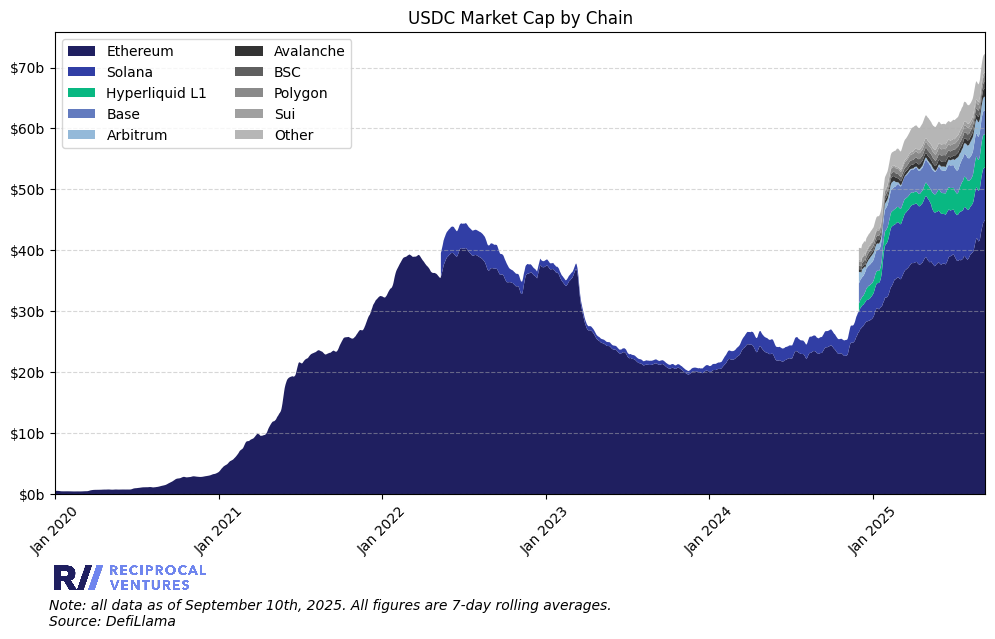

chain       date      Ethereum        Solana  Hyperliquid L1          Base  \
2551  2025-09-05  4.454313e+10  8.848998e+09    5.515877e+09  3.893655e+09   
2552  2025-09-06  4.464369e+10  8.828456e+09    5.503482e+09  3.890916e+09   
2553  2025-09-07  4.475876e+10  8.810289e+09    5.480202e+09  3.890569e+09   
2554  2025-09-08  4.487287e+10  8.686749e+09    5.455510e+09  3.891680e+09   
2555  2025-09-09  4.500746e+10  8.588102e+09    5.447258e+09  3.894208e+09   

chain      Arbitrum     Avalanche           BSC       Polygon           Sui  \
2551   2.198973e+09  1.341244e+09  1.039867e+09  9.892037e+08  5.694414e+08   
2552   2.225998e+09  1.364620e+09  1.039871e+09  9.881815e+08  5.686921e+08   
2553   2.247953e+09  1.384067e+09  1.039873e+09  9.870109e+08  5.685103e+08   
2554   2.276832e+09  1.395290e+09  1.039874e+09  9.854456e+08  5.678974e+08   
2555   2.284694e+09  1.405882e+09  1.039869e+09  9.843407e+08  5.698698e+08   

chain         Other  
2551   2.968369e+09  
2552   2.978

In [185]:
asset = 'USDC'
start_date = '2020-01-01'
end_date = today
n = 9 # number of protocols to show, max is number pulled down in the raw data

stablecoin_mcap_by_chain(asset, start_date, end_date, n)

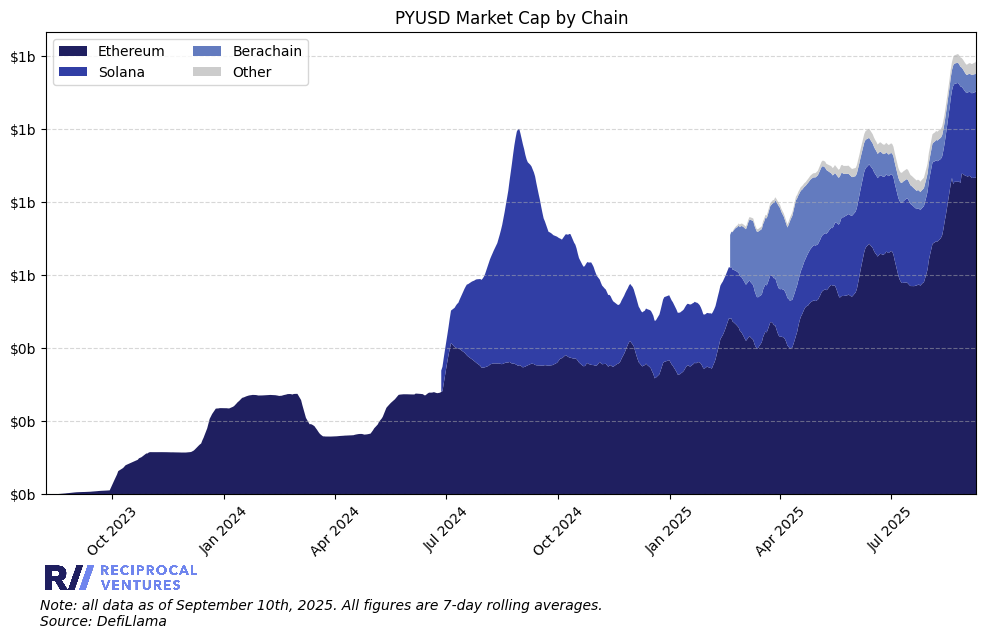

chain       date      Ethereum        Solana     Berachain         Other
759   2025-09-05  8.664026e+08  2.316121e+08  4.972311e+07  3.010514e+07
760   2025-09-06  8.655440e+08  2.325958e+08  4.975349e+07  3.068098e+07
761   2025-09-07  8.663286e+08  2.336665e+08  4.966426e+07  3.125943e+07
762   2025-09-08  8.657369e+08  2.347581e+08  4.956580e+07  3.154434e+07
763   2025-09-09  8.699165e+08  2.349955e+08  4.944837e+07  3.172640e+07


In [186]:
asset = 'PYUSD'
start_date = '2020-01-01'
end_date = today
n = 3 # number of protocols to show, max is number pulled down in the raw data

stablecoin_mcap_by_chain(asset, start_date, end_date, n)

In [187]:
def hyperliquid_as_percent_of_total_usdc(dune_path, messari_path, start_date):
    # Load dune data
    with open(dune_path, 'r') as f:
        dune_data = json.load(f)
    rows = dune_data['result']['rows']
    dune_df = pd.DataFrame(rows)

    # To datetime
    dune_df['date'] = pd.to_datetime(dune_df['date'], format='%Y-%m-%d %H:%M:%S.%f UTC').dt.normalize()
    
    # Load messari data
    with open(messari_path, 'r') as f:
        messari_data = json.load(f)

    points = messari_data['data']['points']
    messari_df = pd.DataFrame(points, columns=[
        'timestamp',
        'circulating-marketcap',
        'circulating-marketcap-dominance',
        'fully-diluted-marketcap'
    ])

    messari_df["date"] = pd.to_datetime(messari_df["timestamp"], unit="s").dt.normalize().ffill()
    messari_df = messari_df[['date','fully-diluted-marketcap']]
    messari_df['USDC Supply'] = messari_df['fully-diluted-marketcap'].rolling(window=7, min_periods=1).mean()

    # Merge datasets for asset slug
    df = pd.merge(messari_df, dune_df, on="date", how="inner")

    # Cut off df to only be after start date
    df = df[df['date'] >= start_date]

    # Calculate Hyperliquid as % of total
    df['USDC on Hyperliquid (Percent of Total)'] = (df['cumulative_amount'] / df['USDC Supply']).rolling(window=7, min_periods=1).mean()


    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax2 = ax1.twinx()

    # Set ax2 to be behind ax1, but make ax1 background transparent
    ax2.set_zorder(1)  # ax2 behind
    ax1.set_zorder(2)  # ax1 in front
    ax1.patch.set_visible(False)  # Make ax1 background transparent
    
    # Line: OI
    ax1.plot(
        df["date"], df["USDC Supply"],
        color="#1f1f60", linewidth=2,
        label="Total USDC Supply",
        zorder=2
    )
    ax1.set_ylabel("Total USDC Supply")
    ax1.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'${x/1e9:,.0f}b'))
    ax1.set_ylim(bottom=0)
    ax1.margins(x=0)                  # no extra padding

    # Monthly ticks, lighter crowding
    ax1.xaxis.set_major_locator(MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
  
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

    # Area: USDC on Hyperliquid (Percent of Total) 
    ax2.fill_between(
        df["date"], df["USDC on Hyperliquid (Percent of Total)"],
        color="#a4a2a8", alpha=1,
        label="USDC on Hyperliquid (Percent of Total)",
        zorder=1
    )
    ax2.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'{x*100:,.0f}%'))
    
    ax2.set_ylabel("Percent of Total USDC Supply")
    ax2.margins(x=0)                  # no extra padding
    ax2.set_ylim(bottom=0)

    # Monthly ticks, lighter crowding
    ax2.xaxis.set_major_locator(MonthLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    
    # Title, grid & legend
    ax1.set_title(f"USDC: Hyperliquid vs Total Supply", fontsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")
    
    # Save & show
    add_logo(ax1, position=(0.075, -0.21))
    plt.figtext(0.075, -0.02, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: Dune Analytics and Messari", ha='left', fontsize=10, style='italic')
    plt.tight_layout()
    plt.savefig(f"{plots_filepath}/hyperliquid_usdc_supply.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Debug print
    print(df.tail(5))
    




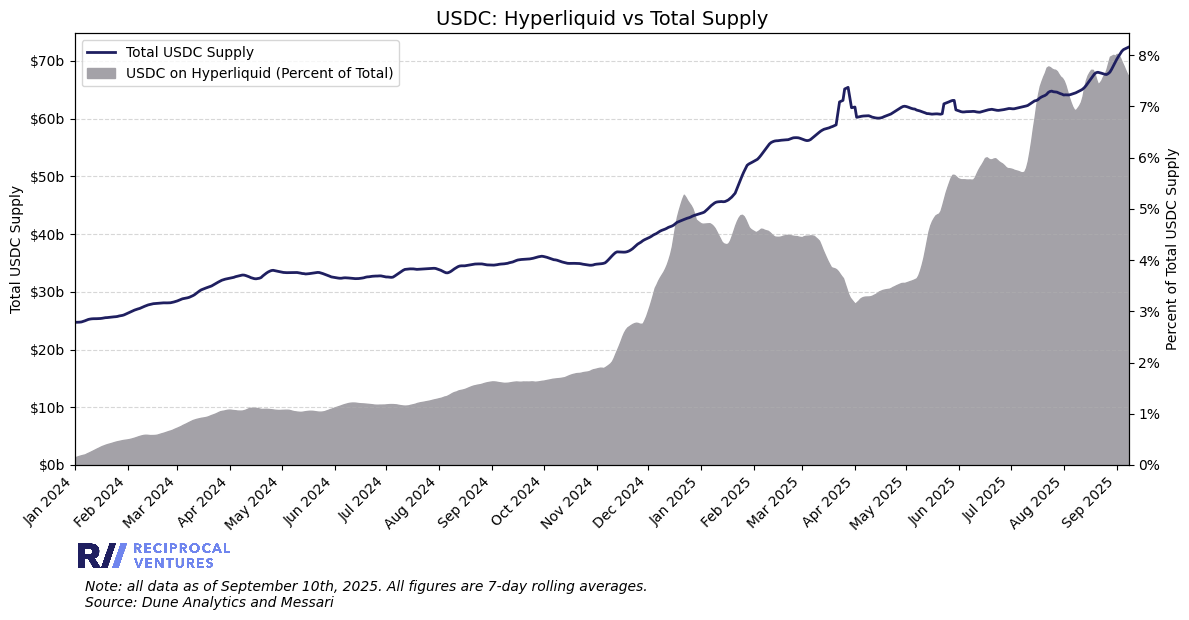

          date  fully-diluted-marketcap   USDC Supply        amount  \
641 2025-09-04             7.268413e+10  7.166697e+10 -6.219456e+07   
642 2025-09-05             7.258473e+10  7.194617e+10  4.444581e+07   
643 2025-09-06             7.256264e+10  7.208966e+10  6.777438e+06   
644 2025-09-07             7.255558e+10  7.223324e+10 -2.823763e+07   
645 2025-09-08             7.251137e+10  7.236890e+10  6.188957e+07   

     cumulative_amount  USDC on Hyperliquid (Percent of Total)  
641       5.392313e+09                                0.078644  
642       5.436759e+09                                0.077926  
643       5.443536e+09                                0.077121  
644       5.415298e+09                                0.076374  
645       5.477188e+09                                0.075810  


In [188]:
# Call the function
dune_path = 'raw-data/dune-raw-data/hyperliquid-usdc-supply.json'
messari_path = 'raw-data/messari-raw-data/asset-data/usdc_marketcap.json'
start_date = '2024-01-01'

hyperliquid_as_percent_of_total_usdc(dune_path, messari_path, start_date)

In [189]:
def top_stablecoins_mcap_by_asset(pegMechanism, stablecoins_filepath, start_date, top_n, ncol):
    asset_colors = ['#1f1f60',
                '#313EA5',
                '#7C9ACC',
                '#ADD8E6',
                '#333333',
                '#494949',
                '#5F5F5F',
                '#757575',
                '#8A8A8A',
                '#A0A0A0',
                '#B6B6B6',
                '#CCCCCC'
               ]
    
    # load protocol map
    with open(stablecoins_filepath, 'r') as f:
        stablecoins_map = json.load(f)

    # Build list of per-protocol token-USD DataFrames
    df_master = None
    for asset_name in stablecoins_map:
        path = f'raw-data/defillama-raw-data/stablecoins/{asset_name}.json'
        with open(path, 'r') as f:
            data = json.load(f)
        entries = data['tokens']
        df = pd.DataFrame(entries)
        df['date'] = pd.to_datetime(df['date'], unit='s').dt.normalize()
        df[f'{asset_name}'] = df['circulating'].apply(lambda x: x.get('peggedUSD'))
        df = df[['date', f'{asset_name}']]

        # Merge dataframes
        df_master = df if df_master is None else df_master.merge(df, on="date", how="outer")
        df_master = df_master.sort_values("date").reset_index(drop=True)
        df_master = df_master.set_index("date")
        df_master = df_master.fillna(0).ffill()

    # Slice to your date window
    start     = pd.Timestamp(start_date).normalize()
    end_date  = (pd.Timestamp.now() - timedelta(days=0)).normalize()
    df_plot   = df_master.loc[start:end_date]
    if df_plot.empty:
        print(f"No data found between {start.date()} and {end_date}.")
        return

    # Pick top include_n assets and roll up the rest
    totals       = df_plot.iloc[-1]
    top_assets   = totals.sort_values(ascending=False).iloc[:top_n].index.tolist()
    other_assets = [c for c in df_plot.columns if c not in top_assets]

    df_top = df_plot[top_assets].copy()
    df_top['Other'] = df_plot[other_assets].sum(axis=1)

    # Determine stacking order:
    #    - take top_assets sorted by descending total (so largest is first → bottom)
    #    - then put 'Other' last → top
    ordered = totals[top_assets].sort_values(ascending=False).index.tolist()
    stack_cols = ordered + ['Other']

    # pick a grey for “Other”
    grey = '#CCCCCC'

    # build the colors list: use the existing palette for the top-N,
    # then force “Other” to grey
    colors = asset_colors[:len(stack_cols)-1] + [grey]

    # now plot
    fig, ax = plt.subplots(figsize=(12,6))
    ax.stackplot(
        df_top.index,
        *[df_top[c] for c in stack_cols],
        labels=stack_cols,
        colors=colors
    )

    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'${x/1e9:.0f}b')
    )

    delta = (end_date - start).days
    if delta < 60:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    else:
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    
    plt.xticks(rotation=45)
    ax.margins(x=0)
    ax.legend(loc='upper left', ncol=ncol, bbox_to_anchor=(0,1))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.075, -0.18))

    
    
    plt.figtext(
        0.12, -0.15,
        f"Note: all data as of {date}.\nOnly includes the top {len(stablecoins_map)} {pegMechanism[1].lower()} stablecoins by mcap.\nSource: DefiLlama",
        ha='left', fontsize=10, style='italic'
    )
    title = f'Top {len(stablecoins_map)} {pegMechanism[1]} Stablecoins by MCap'
    ax.set_title(f'{title}')

    os.makedirs('plots', exist_ok=True)
    plt.savefig(
        f'{plots_filepath}/{title}.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()

    print(df_top.tail())

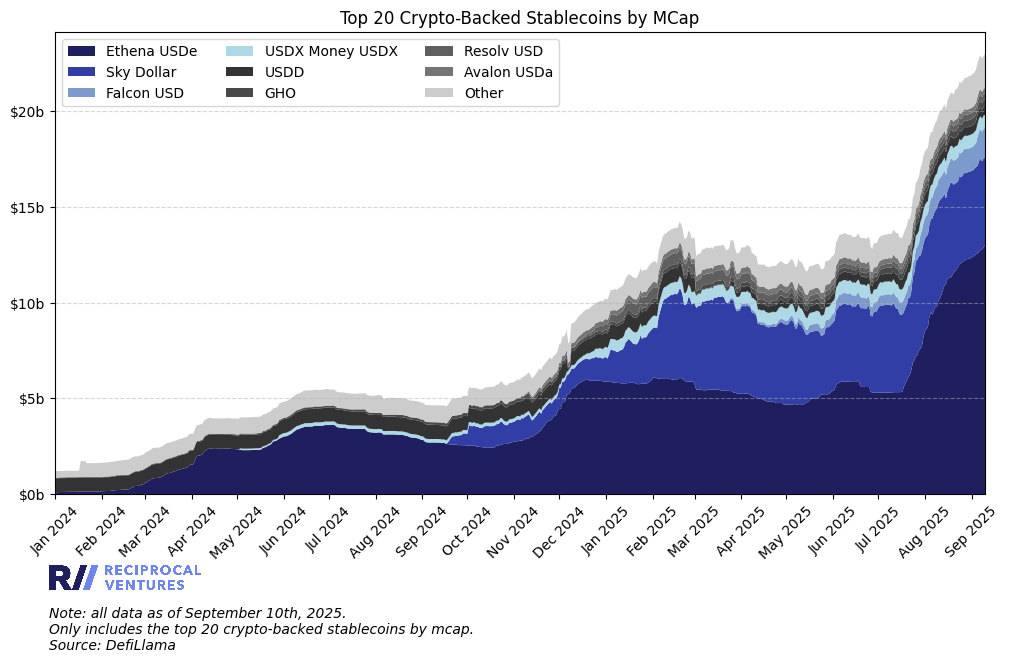

             Ethena USDe    Sky Dollar    Falcon USD  USDX Money USDX  \
date                                                                    
2025-09-06  1.266980e+10  4.738047e+09  1.542244e+09     6.810683e+08   
2025-09-07  1.275359e+10  4.769219e+09  1.546409e+09     6.810622e+08   
2025-09-08  1.278058e+10  4.613009e+09  1.548133e+09     6.810625e+08   
2025-09-09  1.288326e+10  4.671319e+09  1.549215e+09     6.813086e+08   
2025-09-10  1.303321e+10  4.550318e+09  1.550537e+09     6.808530e+08   

                    USDD           GHO    Resolv USD   Avalon USDa  \
date                                                                 
2025-09-06  4.690156e+08  3.504891e+08  3.245481e+08  2.742658e+08   
2025-09-07  4.646173e+08  3.504891e+08  3.243001e+08  2.742658e+08   
2025-09-08  4.487249e+08  3.519528e+08  3.194096e+08  2.742658e+08   
2025-09-09  4.600517e+08  3.519891e+08  3.154189e+08  2.608934e+08   
2025-09-10  4.835640e+08  3.519891e+08  3.120650e+08  2.742593e+08  

In [190]:
pegMechanism = ['crypto-backed', 'Crypto-Backed']
stablecoins_filepath = f'raw-data/defillama-raw-data/top-{pegMechanism[0]}-stablecoins-by-mcap.json'
start_date = '2024-01-01'
top_n = 8
ncol = 3

top_stablecoins_mcap_by_asset(pegMechanism, stablecoins_filepath, start_date, top_n, ncol)

In [191]:
asset_colors = ['#1f1f60',
                '#313EA5',
                '#7C9ACC',
                '#ADD8E6',
                '#333333',
                '#494949',
                '#5F5F5F',
                '#757575',
                '#8A8A8A',
                '#A0A0A0',
                '#B6B6B6',
                '#CCCCCC'
               ]

def sky_collateral_by_asset(start_date, n_assets, n_col):
    dfs = []
    # Convert daily volume json to dataframe
    path = f'raw-data/dune-raw-data/sky-collateral.json'
    with open(path, 'r') as f:
        data = json.load(f)
    entries = data['result']['rows']
    
    # Set up dataframe
    df = pd.DataFrame.from_records(entries)
    df['date'] = pd.to_datetime(df['dt']).dt.tz_localize(None).dt.normalize()
    df_wide = df.pivot(index='date', columns='collateral', values='asset').fillna(0).sort_index()

    # Slice the date window
    start = pd.Timestamp(start_date)
    end_date = pd.Timestamp(datetime.now().date())
    df_plot   = df_wide.loc[start:end_date]
    if df_plot.empty:
        print(f"No data found between {start.date()} and {end_date}.")
        return

    # Pick n assets and roll up the rest
    totals       = df_plot.sum(axis=0)
    top_assets   = totals.nlargest(n_assets).index.tolist()
    other_assets = [c for c in df_plot.columns if c not in top_assets]

    df_top = df_plot[top_assets].copy()
    df_top['Other'] = df_plot[other_assets].sum(axis=1)

    # determine stacking order:
    #    - take top_assets sorted by descending total (so largest is first → bottom)
    #    - then put 'Other' last → top
    ordered = totals[top_assets].sort_values(ascending=False).index.tolist()
    stack_cols = ordered + ['Other']

    # pick a grey for "Other"
    grey = '#CCCCCC'

    # build the colors list: use the existing palette for the top-N,
    # then force "Other" to grey
    colors = asset_colors[:len(stack_cols)-1] + [grey]

    # normalize to 100% per day
    df_pct = df_top.div(df_top.sum(axis=1), axis=0)

    # now plot
    fig, ax = plt.subplots(figsize=(12,6))
    df_pct.plot.area(
        stacked=True,
        ax=ax,
        color=asset_colors[:len(df_pct.columns)-1] + ['#CCCCCC'],
        alpha=0.8
    )

    ax.set_xlabel('')

     # y-axis as %
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_ylim(0,1)

    # Manually create month ticks - bypassing pandas date handling
    delta = (end_date - start).days
    if delta < 60:
        # For short periods, use weekly ticks
        tick_dates = pd.date_range(start=start, end=end_date, freq='W-MON')
        tick_labels = [d.strftime('%b %d') for d in tick_dates]
    else:
        # For longer periods, use monthly ticks
        tick_dates = pd.date_range(start=start, end=end_date, freq='2MS')  # Every 2 months
        tick_labels = [d.strftime('%b %Y') for d in tick_dates]
    
    # Set the ticks manually
    ax.set_xticks(tick_dates)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
   
    ax.minorticks_off()
    
    ax.margins(x=0)
    ax.legend(loc='lower right', ncol=n_col, bbox_to_anchor=(1,-0.3))
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    last_date = df_top.index.max().date()
    add_logo(ax, position=(0.075, -0.22))
    
    plt.figtext(
        0.12, -0.05,
        f"Note: all data as of {date}. \n{len(other_assets)} assets included in 'Other'.\nSource: Dune Analytics",
        ha='left', fontsize=10, style='italic'
    )
    ax.set_title('Sky Collateral')

    os.makedirs('plots', exist_ok=True)
    plt.savefig(
        f'{plots_filepath}/sky-collateral-100%.png',
        dpi=300, bbox_inches='tight'
    )
    plt.show()

    print(df_pct.tail())

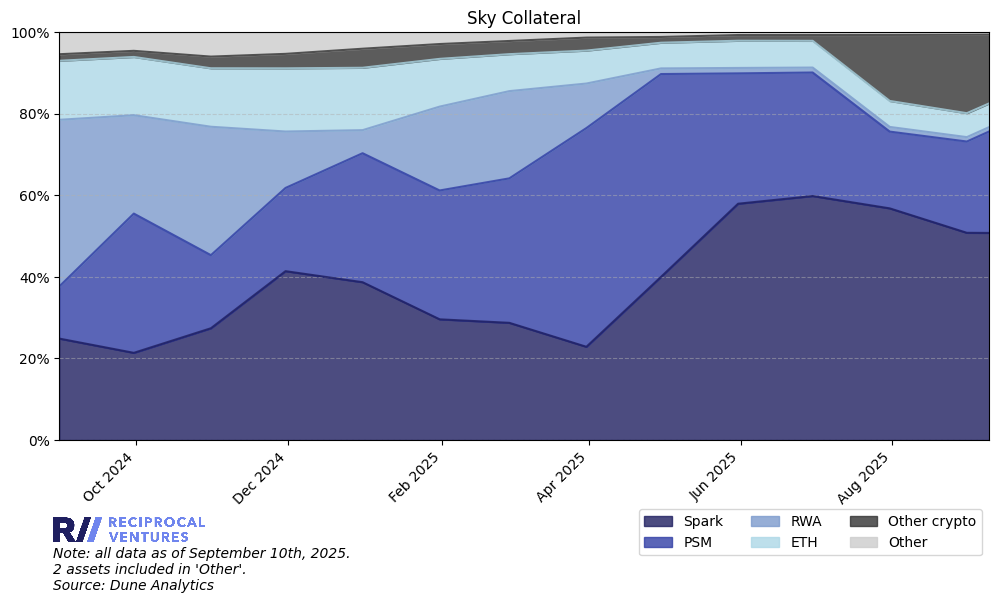

collateral     Spark       PSM       RWA       ETH  Other crypto     Other
date                                                                      
2025-05-31  0.579127  0.319511  0.013288  0.066655      0.014008  0.007412
2025-06-30  0.597987  0.302763  0.012128  0.065492      0.014369  0.007261
2025-07-31  0.567722  0.188165  0.011488  0.063602      0.161861  0.007161
2025-08-31  0.507836  0.223744  0.010804  0.058594      0.192292  0.006730
2025-09-09  0.507556  0.248723  0.010711  0.058073      0.168405  0.006532


In [192]:
start_date = '2024-08-01'
n_assets = 5
n_col = 3

sky_collateral_by_asset(start_date, n_assets, n_col)

In [193]:
def plot_supply_multi_asset(assets, start_date, title, ncol):
    df_master = None
    
    for asset_slug, asset_name in assets.items():
        # Load supply data
        supply_path = f"raw-data/messari-raw-data/asset-data/{asset_slug}_supply.json"
        with open(supply_path, 'r') as f:
            supply_data = json.load(f)

        points = supply_data['data']['points']
        interim_df = pd.DataFrame(points, columns=[
            'time',
            'circulating-supply',
            'total-supply'
        ])

        interim_df["date"] = pd.to_datetime(interim_df["time"], unit="s")
        interim_df[f'{asset_name}'] = interim_df['circulating-supply'].rolling(window=7, min_periods=1).mean()
        interim_df = interim_df[['date',f'{asset_name}']]

        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.ffill()
        df_master = df_master.fillna(0)
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]

    # Get the asset names and sort them by their last day's value (descending)
    asset_list = list(assets.values())
    last_day_values = df_master.iloc[-1]  # Get the last row
    print(last_day_values)
    
    # Create list of (asset_name, last_value) tuples and sort by value descending
    asset_value_pairs = [(asset, last_day_values[asset]) for asset in asset_list]
    asset_value_pairs.sort(key=lambda x: x[1], reverse=True)
    
    # Extract the sorted asset names
    sorted_asset_list = [pair[0] for pair in asset_value_pairs]

    # Prepare the values and colors in the sorted order
    dates = df_master['date']
    series = [df_master[asset] for asset in asset_list]
    colors = asset_colors[:len(asset_list)]
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors (now sorted by descending last day value)
    ax.stackplot(
        dates,
        *series,
        labels=asset_list,
        colors=colors
    )
    
    # Setting labels and title
    ax.set_title(title)
    ax.margins(x=0)
    delta = (today - df_master['date'].iloc[0]).days
    if delta < 60:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    elif delta < 1200:
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    
    else:
        ax.xaxis.set_major_locator(YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e9:,.0f}b'))

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='upper left', ncol=ncol, bbox_to_anchor=(0,1))
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: Messari",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{title}.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

date     2025-09-10 00:00:00
BUSD         55026240.205946
USDP         67810611.127143
USDG        549232390.274286
PYUSD      1179378715.063569
Name: 2444, dtype: object


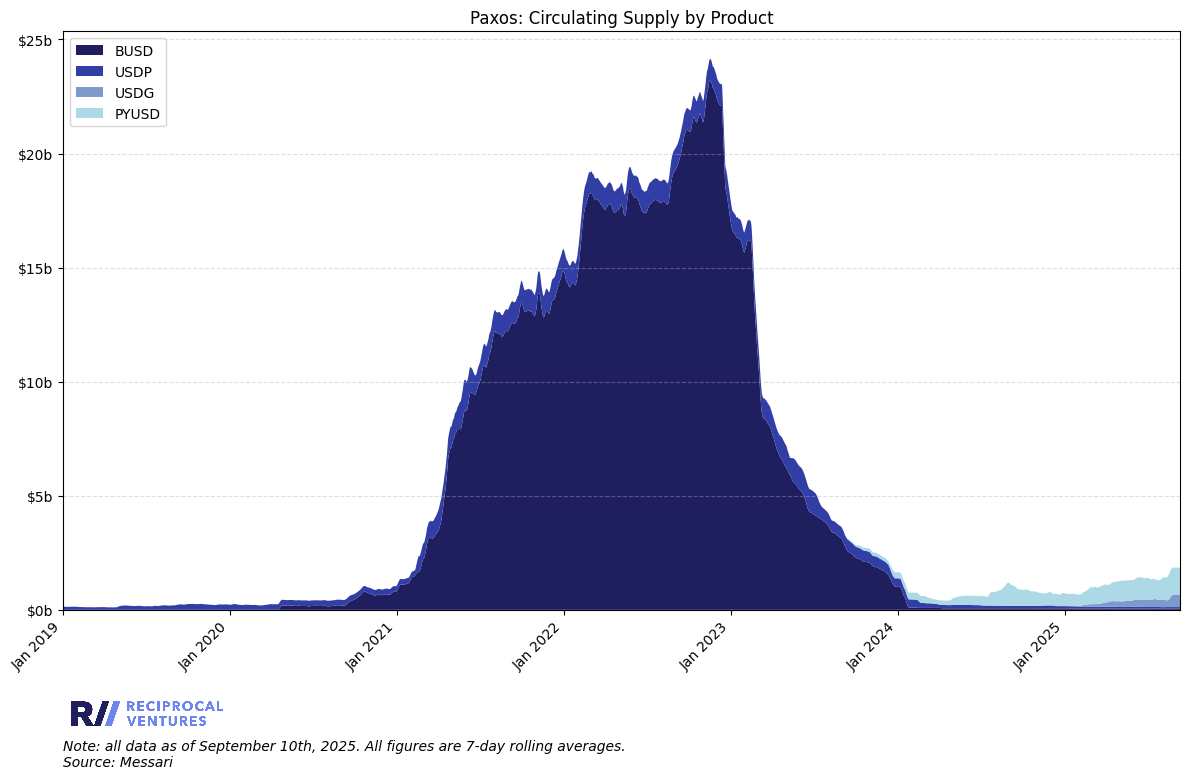

In [194]:
assets = {'busd': 'BUSD',
          'usdp': 'USDP',
          'usdg': 'USDG',
          'pyusd': 'PYUSD'
             }
start_date = '2019-01-01'
title = 'Paxos: Circulating Supply by Product'
ncol = 1

plot_supply_multi_asset(assets, start_date, title, ncol)

date     2025-09-10 00:00:00
USDP         67810611.127143
PYUSD      1179378715.063569
Name: 2444, dtype: object


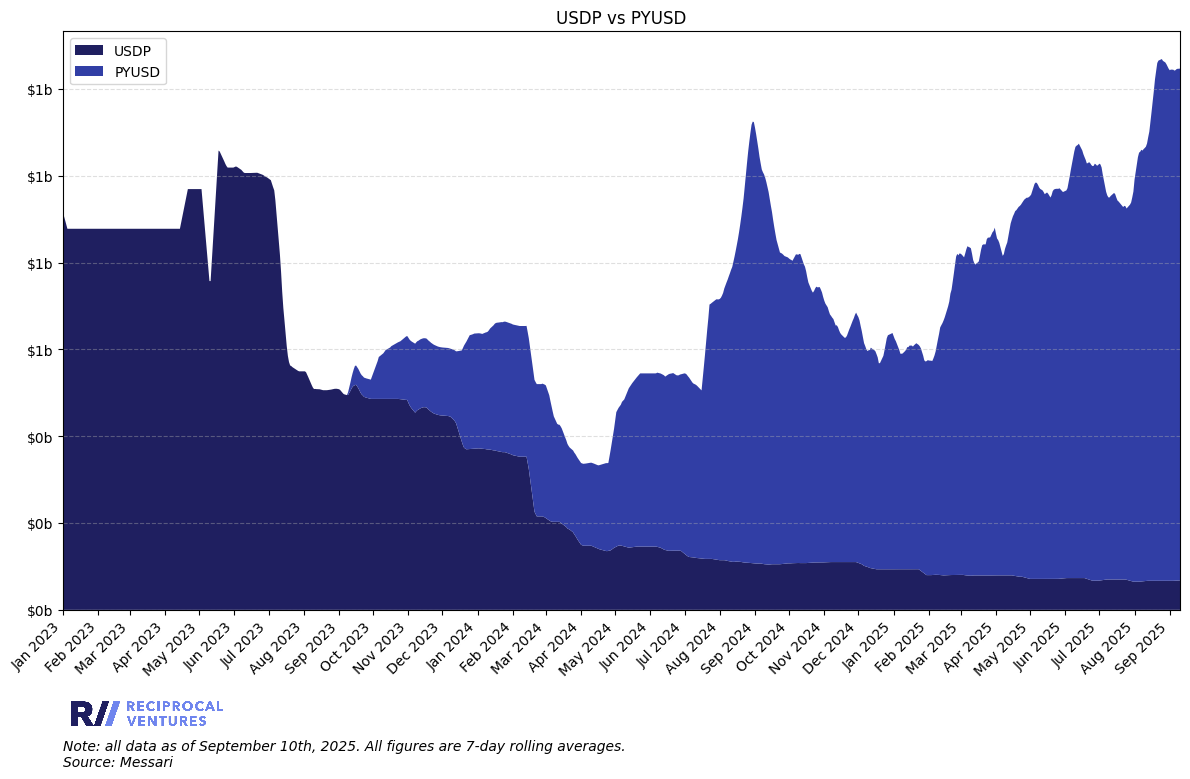

In [195]:
assets = {'usdp': 'USDP',
          'pyusd': 'PYUSD'
             }
start_date = '2023-01-01'
title = 'USDP vs PYUSD'
ncol = 1

plot_supply_multi_asset(assets, start_date, title, ncol)

date     2025-09-10 00:00:00
USDe      12746382374.537144
PYUSD      1179378715.063569
Name: 752, dtype: object


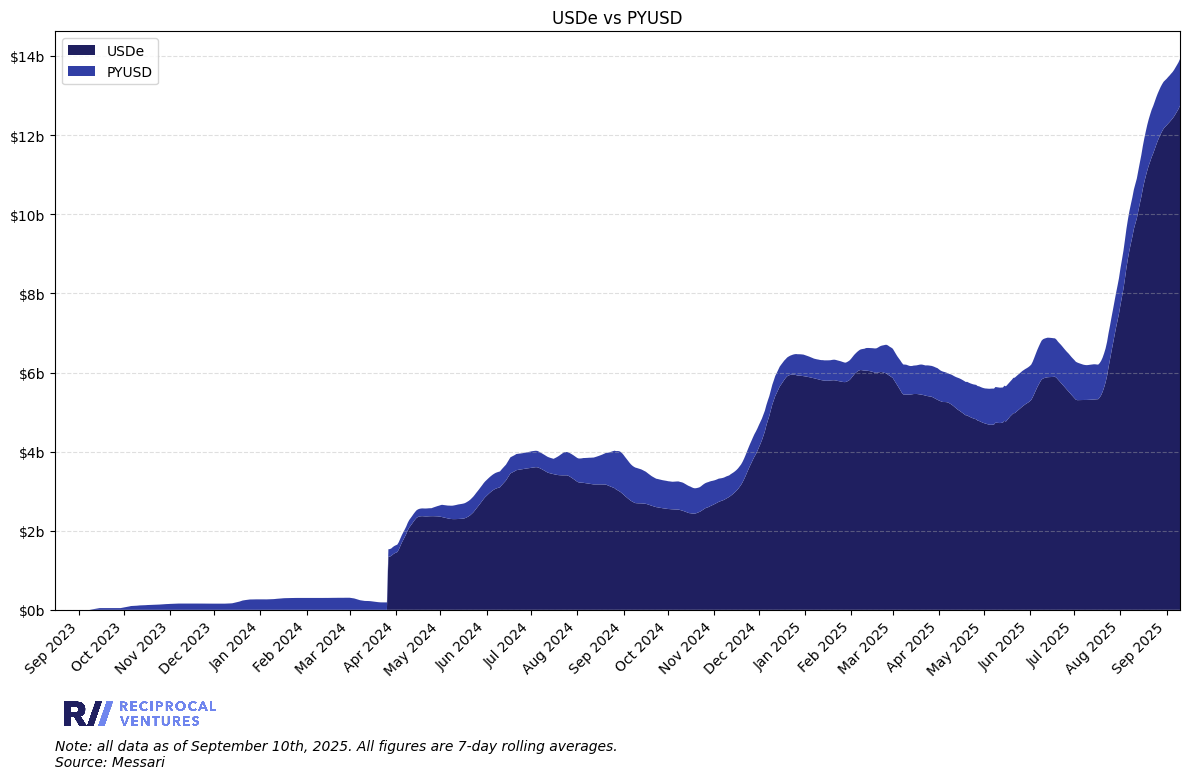

In [213]:
assets = {'usde': 'USDe',
          'pyusd': 'PYUSD'
             }
start_date = '2023-01-01'
title = 'USDe vs PYUSD'
ncol = 1

plot_supply_multi_asset(assets, start_date, title, ncol)

In [209]:
def plot_supply_as_percent_of_other_asset(assets, start_date, title, ncol):
    df_master = None

    asset_names = []
    
    for asset_slug, asset_name in assets.items():
        # Load supply data
        supply_path = f"raw-data/messari-raw-data/asset-data/{asset_slug}_supply.json"
        with open(supply_path, 'r') as f:
            supply_data = json.load(f)

        points = supply_data['data']['points']
        interim_df = pd.DataFrame(points, columns=[
            'time',
            'circulating-supply',
            'total-supply'
        ])

        interim_df["date"] = pd.to_datetime(interim_df["time"], unit="s")
        interim_df[f'{asset_name}'] = interim_df['circulating-supply']
        interim_df = interim_df[['date',f'{asset_name}']]
        asset_names.append(asset_name)

        # Merge asset dataframe into the master dataframe
        df_master = interim_df if df_master is None else df_master.merge(interim_df, on="date", how="outer")
        df_master = df_master.ffill()
        df_master = df_master.fillna(0)
        df_master = df_master.sort_values("date").reset_index(drop=True)

    # Execute data cut
    df_master[f'{asset_names[0]} as % of {asset_names[1]}'] = (df_master[f'{asset_names[0]}'] / df_master[f'{asset_names[1]}']).rolling(window=7, min_periods=1).mean()

    # Cut off df_master to only be after start date
    df_master = df_master[df_master['date'] >= start_date]
    
    # Create the line chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plotting the line chart with custom colors (now sorted by descending last day value)
    ax.fill_between(
        df_master["date"], df_master[f'{asset_names[0]} as % of {asset_names[1]}'],
        color="#a4a2a8", alpha=1,
        label=f'{asset_names[0]} as % of {asset_names[1]}'
    )
    
    # Setting labels and title
    ax.set_title(title)
    ax.margins(x=0)
    delta = (today - df_master['date'].iloc[0]).days
    if delta < 60:
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=MO, interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    elif delta < 1200:
        ax.xaxis.set_major_locator(MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    
    else:
        ax.xaxis.set_major_locator(YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x*100:,.1f}%'))
    ax.set_ylim(bottom=0)

    # Add grid lines for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Add logo
    add_logo(ax, position=(0.075, -0.18))
    
    # Add sources and note
    text_box = ax.text(0, -0.27, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: Messari",
                       ha='left', transform=ax.transAxes, fontsize=10,
                       bbox=dict(facecolor='white', alpha=0), fontstyle='italic')
    
    # Ensure the layout adapts to fit all elements (legend, text, etc.)
    plt.tight_layout()
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{title}.png", dpi=300, bbox_inches='tight')
    
    # Show
    plt.show()

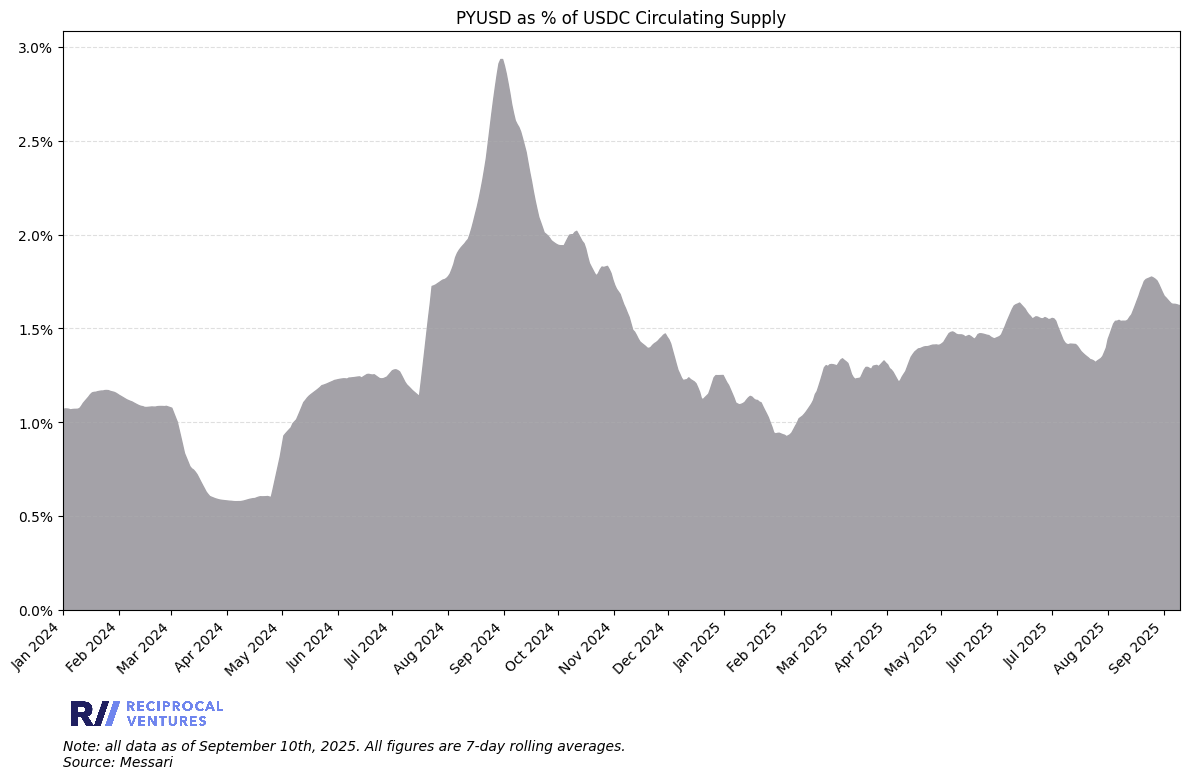

In [212]:
assets = {'pyusd': 'PYUSD',
          'usdc': 'USDC',
             }
start_date = '2024-01-01'
title = 'PYUSD as % of USDC Circulating Supply'
ncol = 1

plot_supply_as_percent_of_other_asset(assets, start_date, title, ncol)